In [2]:
## !pip install fredapi

from fredapi import Fred
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Accessing FRED's Federal Funds Effective Rate (DFF) API

One of the literature papers that we reviewed suggested using the Federal Funds Rate as an indicator for stablecoins depegging. For our project, we obtain the Federal Funds Rate data from the Federal Reserve Economic Data (FRED) API. 

*NOTE: We accessed FRED's DFF series to obtain the daily Federal Funds Rate data. FRED has another series on Federal Funds Rate, named FEDFUNDS, but that series of data is on a monthly resolution instead.*

In [3]:
FRED_API_KEY = "084a38e9d6fd82146cf89b8c30eba224"

fred = Fred(api_key= FRED_API_KEY)
fedfunds = fred.get_series("DFF")

fedfunds = fedfunds.to_frame().reset_index()
fedfunds.columns = ["date", "fed_funds_rate"] ## rename dataframe columns
fedfunds

,date,fed_funds_rate
0,1954-07-01,1.13
1,1954-07-02,1.25
2,1954-07-03,1.25
3,1954-07-04,1.25
4,1954-07-05,0.88
...,...,...
26204,2026-03-29,3.64
26205,2026-03-30,3.64
26206,2026-03-31,3.64
26207,2026-04-01,3.64


## Data Quality Checks and Cleaning

The data types of the columns in the dataset seem alright. The `date` column is already in datetime format (albeit missing a UTC timezone), and the `fed_funds_rate` column is a float representing the Fed Funds Rate on that date. 

In [4]:
fedfunds.dtypes

date              datetime64[ns]
fed_funds_rate           float64
dtype: object

In [5]:
fedfunds["date"] = pd.to_datetime(fedfunds["date"], utc = True)

start_date = pd.to_datetime("2020-11-25", utc = True) ## standardized to the start date of cleaned_ustc.csv
end_date = pd.to_datetime("2026-03-19", utc = True) ## standardized to the end date of cleaned_ustc.csv

fedfunds = fedfunds[(fedfunds["date"] >= start_date) & (fedfunds["date"] <= end_date)].reset_index(drop = True) ## keep only the data for the date range we are interested in
fedfunds

,date,fed_funds_rate
0,2020-11-25 00:00:00+00:00,0.08
1,2020-11-26 00:00:00+00:00,0.08
2,2020-11-27 00:00:00+00:00,0.08
3,2020-11-28 00:00:00+00:00,0.08
4,2020-11-29 00:00:00+00:00,0.08
...,...,...
1936,2026-03-15 00:00:00+00:00,3.64
1937,2026-03-16 00:00:00+00:00,3.64
1938,2026-03-17 00:00:00+00:00,3.64
1939,2026-03-18 00:00:00+00:00,3.64


There are also no missing data in the Federal Funds Rate dataset. No cleaning is required.

In [6]:
fedfunds.isnull().any()

date              False
fed_funds_rate    False
dtype: bool

From the chart below, we can see that there is a clear and steady climb in the Federal Funds Rate in the pre-crash and crash periods.

In [7]:
crash_start = pd.to_datetime("2022-05-09", utc = True) ## crash_start date defined in cleaned_ustc.ipynb
pre_crash_start = pd.to_datetime("2022-05-02", utc = True) ## pre_crash_start date defined in cleaned_ustc.ipynb
crash_end = pd.to_datetime("2023-01-31", utc = True) ## crash_end date defined in cleaned_ustc.ipynb
post_crash_end = pd.to_datetime("2023-02-07", utc = True) ## post_crash_end date defined in cleaned_ustc.ipynb

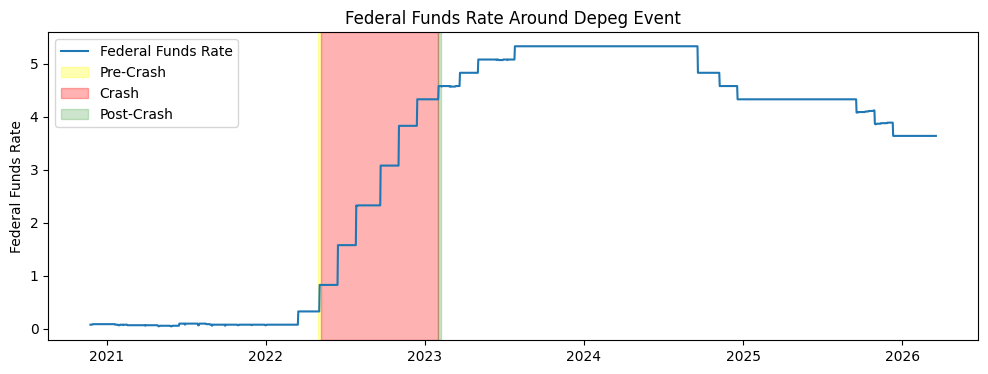

In [8]:
plt.figure(figsize=(12,4))
plt.plot(fedfunds["date"], fedfunds["fed_funds_rate"], label = "Federal Funds Rate")
plt.axvspan(pre_crash_start, crash_start, color = 'yellow', alpha = 0.3, label = "Pre-Crash")
plt.axvspan(crash_start, crash_end, color = 'red', alpha = 0.3, label = "Crash")
plt.axvspan(crash_end, post_crash_end, color = 'green', alpha = 0.2, label = "Post-Crash")

plt.title("Federal Funds Rate Around Depeg Event")
plt.ylabel("Federal Funds Rate")
plt.legend()
plt.show()

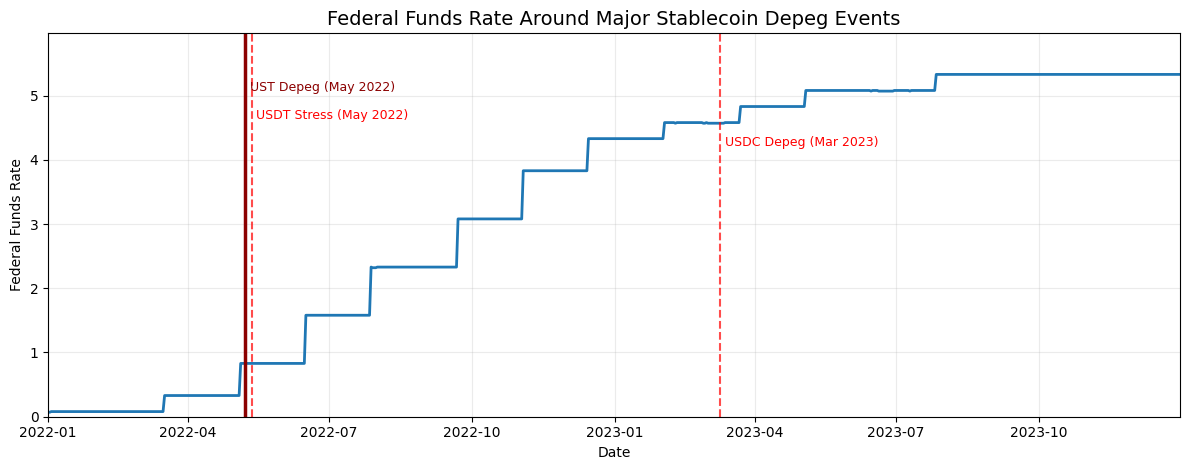

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# make sure date column is datetime
fedfunds["date"] = pd.to_datetime(fedfunds["date"])

# major event dates
event_dates = {
    "UST Depeg (May 2022)": "2022-05-08",
    "USDT Stress (May 2022)": "2022-05-12",
    "USDC Depeg (Mar 2023)": "2023-03-10"
}

plt.style.use("default")
plt.figure(figsize=(12, 4.8))

# main line
plt.plot(
    fedfunds["date"],
    fedfunds["fed_funds_rate"],
    linewidth=2,
    label="Federal Funds Rate"
)

# get max y for label placement
y_max = fedfunds["fed_funds_rate"].max()

y_positions = [0.98, 0.90, 0.82]

for (label, date), y_pos in zip(event_dates.items(), y_positions):
    date = pd.to_datetime(date)

    if "UST" in label:
        plt.axvline(date, color="darkred", linewidth=2.5)
    else:
        plt.axvline(date, color="red", linestyle="--", linewidth=1.5, alpha=0.7)

    plt.text(
        date + pd.Timedelta(days=3),
        y_max * y_pos,
        label,
        fontsize=9,
        color="darkred" if "UST" in label else "red",
        ha="left",
        va="top"
    )

# focus on relevant period
plt.xlim(pd.to_datetime("2022-01-01"), pd.to_datetime("2023-12-31"))
plt.ylim(0, y_max * 1.12)

# labels and title
plt.title("Federal Funds Rate Around Major Stablecoin Depeg Events", fontsize=14)
plt.ylabel("Federal Funds Rate")
plt.xlabel("Date")

# clean up
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Exporting Cleaned Dataset

In [11]:
#fedfunds.to_csv("../raw_data/fed_funds_rate.csv", index = False)